## 1. Problem Definition & Data Collection

**Objective:** Predict the price of new & used Mobile phones based on attributes like Brand, RAM, Storage

**Dataset:** A collection of used Mobile phone listings


# Preprocessing

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('../data/phone-details/phone_dataset.csv')
print(f"Initial dataset: {data.shape[0]} rows, {data.shape[1]} columns")
data.head()

Initial dataset: 1039 rows, 16 columns


,Price,Condition,Brand,Model,Edition,Operating System,RAM,Memory,No. of Camera,Screen Size,Battery,SIM Support,Features,Description,Network,Processor
0,35000,Used,Samsung,Galaxy A13,Samsung,Android,6 GB,128 GB,Quad,Above 6 inches,5000 mAh,Dual SIM,"USB Type-C Port, Fast Charging, Flash Charging...",Ex change I phone,NaN,NaN
1,102000,Used,Apple,iPhone 13 Pro Max,128GB,iOS,NaN,128 GB,Triple,NaN,NaN,Single SIM,NaN,iPhone 13pro max | 128GB | Top condition | No ...,5G,NaN
2,14000,Used,Samsung,Galaxy A03s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Full set | සුපිරිම තියෙනවා,NaN,NaN
3,18000,Used,Samsung,Galaxy A12,NaN,Android,4 GB,64 GB,Quad,Above 6 inches,5000 mAh,Dual SIM,"USB Type-C Port, Fast Charging, Flash Charging...",no scratches or damage to screen | fingerprint...,4G,MediaTek
4,126000,Used,Apple,iPhone 14,NaN,iOS,6 GB,256 GB,Dual,5.1 to 6 inches,4000 mAh,Dual VoLTE,"Fast Charging, Bluetooth, Wifi, GPS",I phone 14 256GB | 🛑 Condition 💯 | 🛑 Battery h...,5G,NaN


In [2]:
data.isnull().sum()

Price                 0
Condition             0
Brand                 0
Model                 0
Edition             280
Operating System    137
RAM                 407
Memory              198
No. of Camera       364
Screen Size         563
Battery             558
SIM Support         335
Features            338
Description           0
Network             291
Processor           730
dtype: int64

Fill mising value for Network/SIM Ssupport with mode of other rows with same model


In [3]:
overall_mode_network = data['Network'].mode()[0] if not data['Network'].mode().empty else 'Unknown'
data['Network'] = data.groupby('Model')['Network'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else overall_mode_network))
data['Network'].fillna(overall_mode_network, inplace=True)

In [4]:
overall_mode_sim_support = data['SIM Support'].mode()[0] if not data['SIM Support'].mode().empty else 'Unknown'
data['SIM Support'] = data.groupby('Model')['SIM Support'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else overall_mode_sim_support))
data['SIM Support'].fillna(overall_mode_sim_support, inplace=True)

Fill missing values in RAM and Memmory with median of other rows with same model

In [5]:
data['RAM'] = data['RAM'].str.extract('(\d+)').astype(float)
overall_median_ram = data['RAM'].median()
data['RAM'] = data.groupby('Model')['RAM'].transform(lambda x: x.fillna(x.median()))
data['RAM'].fillna(overall_median_ram, inplace=True)

In [6]:
data['Memory'] = data['Memory'].str.extract('(\d+)').astype(float)
overall_median_memory = data['Memory'].median()
data['Memory'] = data.groupby('Model')['Memory'].transform(lambda x: x.fillna(x.median()))
data['Memory'].fillna(overall_median_memory, inplace=True)

Change data type to int32 on RAM and Memory

In [7]:
data['RAM'] = data['RAM'].astype('int32')
data['Memory'] = data['Memory'].astype('int32')

Make brands column comfortable with one-hot encoding

In [8]:
brand_counts = data['Brand'].value_counts()
brands_to_replace = brand_counts[brand_counts < 20].index
data['Brand'] = data['Brand'].replace(brands_to_replace, 'Other brand')

Remove "model" since it have lot of classes

In [9]:
print(data['Model'].value_counts())

Model
Other model      73
iPhone 11        46
iPhone 12        32
iPhone SE 2      26
iPhone 11 Pro    25
                 ..
Reno 12           1
A5                1
Mi 3              1
11 Lite NE        1
C25               1
Name: count, Length: 271, dtype: int64


In [10]:
columns_to_drop = [
    'Edition',
    'Operating System',
    'No. of Camera',
    'Screen Size',
    'Battery',
    'Features',
    'Description',
    'Processor',
    'Model'
]
data.drop(columns=columns_to_drop, inplace=True)

In [11]:
data.isnull().sum()

Price          0
Condition      0
Brand          0
RAM            0
Memory         0
SIM Support    0
Network        0
dtype: int64

In [32]:
data.to_csv('../data/phone-details/cleaned_my_dataset.csv', index=False)

One-Hot Encoding of dataset

In [13]:
data2=pd.get_dummies(data)

In [14]:
print(f"Number of columns in data2: {data2.shape[1]}")
print(f"Number of rows in data2: {data2.shape[0]}")

Number of columns in data2: 20
Number of rows in data2: 1039


## Model Training
Here I useRandom Forest Regressor.

In [15]:
X=data2.drop('Price',axis=1)
y=data2['Price']

Split dataset to train-test

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

Define function to evaluate accuracy

In [17]:
def model_acc(model):
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(str(model)+ ' --> ' +str(acc))

In [18]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)
model_acc(rf)

RandomForestRegressor(max_depth=15, min_samples_split=5, random_state=42) --> 0.8207388730834595


## Model Persistence

Save the trained model and related artifacts for future use without retraining.

In [19]:
import os
import json
from datetime import datetime

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# 1. Save the trained Random Forest model
model_path = '../models/random_forest_phone_price_model.pkl'
joblib.dump(rf, model_path)
print(f"✅ Model saved to: {model_path}")

# 2. Save feature names (critical for making predictions later)
feature_names = X_train.columns.tolist()
feature_path = '../models/feature_names.json'
with open(feature_path, 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f"✅ Feature names saved to: {feature_path}")

# 3. Save model metadata
metadata = {
    'model_type': 'RandomForestRegressor',
    'training_samples': X_train.shape[0],
    'testing_samples': X_test.shape[0],
    'n_features': X_train.shape[1],
    'trained_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

metadata_path = '../models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Model metadata saved to: {metadata_path}")

print("\n" + "="*50)
print("All model artifacts saved successfully!")
print("="*50)

✅ Model saved to: ../models/random_forest_phone_price_model.pkl
✅ Feature names saved to: ../models/feature_names.json
✅ Model metadata saved to: ../models/model_metadata.json

All model artifacts saved successfully!


## Evaluation Metrics

------------------------------
Model Performance Results:
✅ Accuracy (R² Score): 0.8207 (82.07%)
❌ Mean Absolute Error: Rs. 19,360.26
❌ RMSE:                Rs. 30,038.62
------------------------------


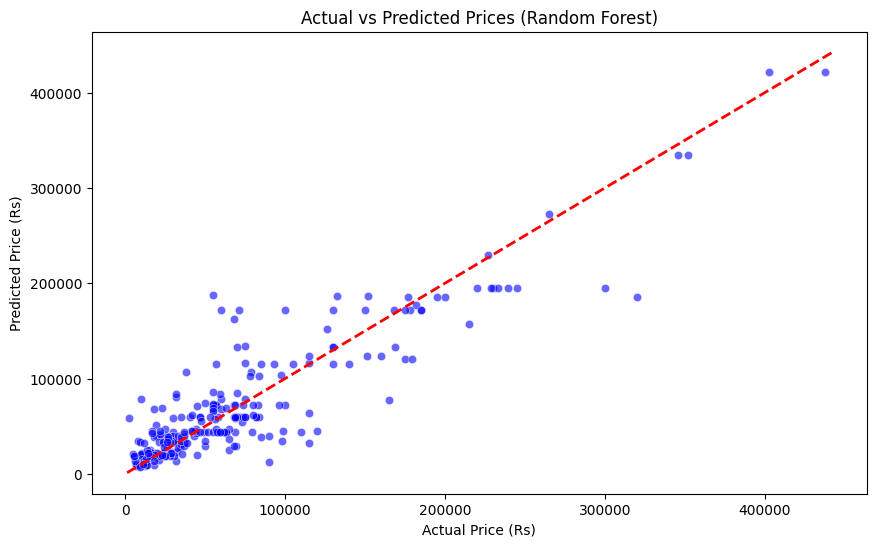

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = rf.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("-" * 30)
print(f"Model Performance Results:")
print(f"✅ Accuracy (R² Score): {r2:.4f} ({r2*100:.2f}%)")
print(f"❌ Mean Absolute Error: Rs. {mae:,.2f}")
print(f"❌ RMSE:                Rs. {rmse:,.2f}")
print("-" * 30)

# Visualizing Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Ideal line
plt.xlabel("Actual Price (Rs)")
plt.ylabel("Predicted Price (Rs)")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.show()

In [21]:
# Save evaluation metrics
metrics = {
    'r2_score': float(r2),
    'mean_absolute_error': float(mae),
    'root_mean_squared_error': float(rmse),
    'r2_percentage': float(r2 * 100),
    'evaluation_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'test_samples': len(y_test)
}

metrics_path = '../models/evaluation_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"✅ Evaluation metrics saved to: {metrics_path}")
print(f"\nSaved metrics:")
for key, value in metrics.items():
    if 'error' in key.lower() or 'rmse' in key.lower():
        print(f"  - {key}: Rs. {value:,.2f}")
    elif 'percentage' in key.lower():
        print(f"  - {key}: {value:.2f}%")
    elif 'score' in key.lower():
        print(f"  - {key}: {value:.4f}")
    else:
        print(f"  - {key}: {value}")

✅ Evaluation metrics saved to: ../models/evaluation_metrics.json

Saved metrics:
  - r2_score: 0.8207
  - mean_absolute_error: Rs. 19,360.26
  - root_mean_squared_error: Rs. 30,038.62
  - r2_percentage: 82.07%
  - evaluation_date: 2026-02-23 15:39:37
  - test_samples: 260


## Explainability (XAI)
SHAP (SHapley Additive exPlanations)

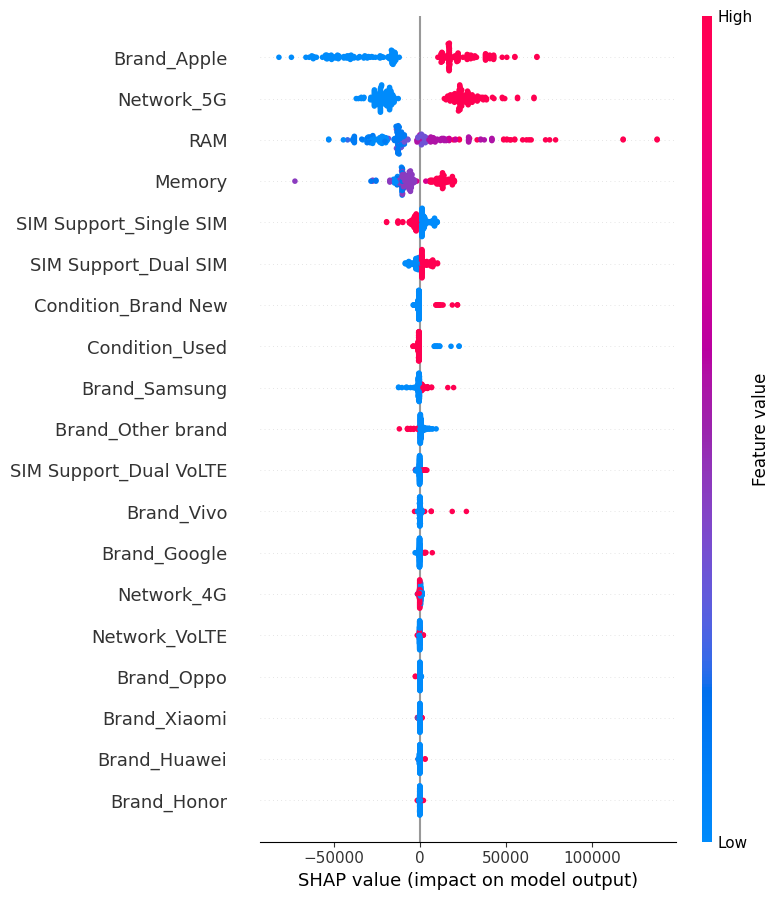

Dependence Plot: Effect of RAM


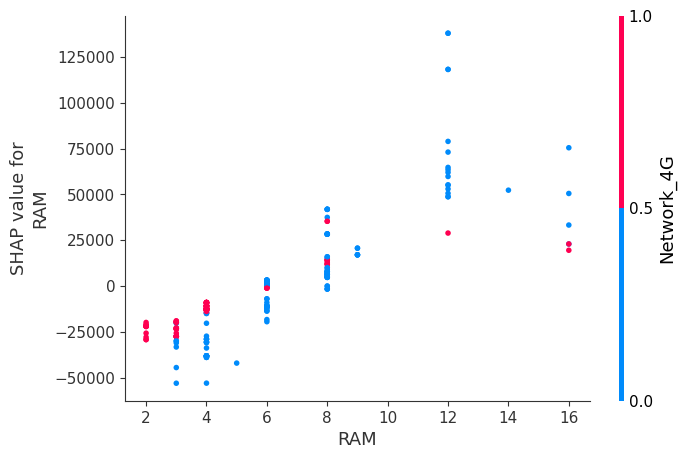

In [27]:
import shap
# Initialize JS visualization code
shap.initjs()

# Create TreeExplainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# 1. Summary Plot (Feature Importance)
plt.figure(figsize=(12, 8))
plt.title("Feature Importance (SHAP Summary)")
shap.summary_plot(shap_values, X_test, show=False)
plt.show()

# 2. Dependence Plot for 'manufacture_year'
# This shows how the Year affects the price prediction
print("Dependence Plot: Effect of RAM")
shap.dependence_plot("RAM", shap_values, X_test)

In [31]:
# Load the saved model
loaded_model = joblib.load('../models/random_forest_phone_price_model.pkl')
print("✅ Model loaded successfully!")

# Load feature names
with open('../models/feature_names.json', 'r') as f:
    saved_features = json.load(f)
print(f"✅ Loaded {len(saved_features)} feature names")

# Load metadata
with open('../models/model_metadata.json', 'r') as f:
    saved_metadata = json.load(f)
print(f"✅ Model was trained on: {saved_metadata['trained_date']}")

# Example: Make a prediction using the loaded model
# Take the first 5 samples from test set
sample_data = X_test.head(5)
sample_predictions = loaded_model.predict(sample_data)

print("\n" + "="*60)
print("Sample Predictions")
print("="*60)
for i, (idx, row) in enumerate(sample_data.iterrows()):
    actual_price = y_test.loc[idx]
    predicted_price = sample_predictions[i]
    print(f"\nSample {i+1}:")
    print(f"  Actual Price:    Rs. {actual_price:,.0f}")
    print(f"  Predicted Price: Rs. {predicted_price:,.0f}")
    print(f"  Difference:      Rs. {abs(actual_price - predicted_price):,.0f}")

✅ Model loaded successfully!
✅ Loaded 19 feature names
✅ Model was trained on: 2026-02-23 15:39:06

Sample Predictions

Sample 1:
  Actual Price:    Rs. 79,000
  Predicted Price: Rs. 106,996
  Difference:      Rs. 27,996

Sample 2:
  Actual Price:    Rs. 24,000
  Predicted Price: Rs. 23,262
  Difference:      Rs. 738

Sample 3:
  Actual Price:    Rs. 75,000
  Predicted Price: Rs. 78,398
  Difference:      Rs. 3,398

Sample 4:
  Actual Price:    Rs. 29,999
  Predicted Price: Rs. 34,638
  Difference:      Rs. 4,639

Sample 5:
  Actual Price:    Rs. 18,000
  Predicted Price: Rs. 38,645
  Difference:      Rs. 20,645
